# Integrated Time-Series Analysis: NVDA
## From Raw Data to ML-Ready Features

This notebook demonstrates the end-to-end pipeline developed in this repository. We will:
1. **Load** data from the DuckDB warehouse.
2. **Decompose** the signal into Trend and Seasonality.
3. **Transform** the data for Stationarity.
4. **Engineer** features with data leakage protection.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from stationarity_test import check_stationarity
from preprocessing import TimeSeriesPreprocessor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

### 1. Data Ingestion
Pulling the latest NVDA records from our local DuckDB instance.

In [2]:
with duckdb.connect("stocks.db") as con:
    df = con.execute("SELECT * FROM stock_prices WHERE ticker = 'NVDA' ORDER BY date").df()

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
print(f"Loaded {len(df)} rows of NVDA data.")

Loaded 1255 rows of NVDA data.


### 2. STL Decomposition
Isolating the structural components of the price series.

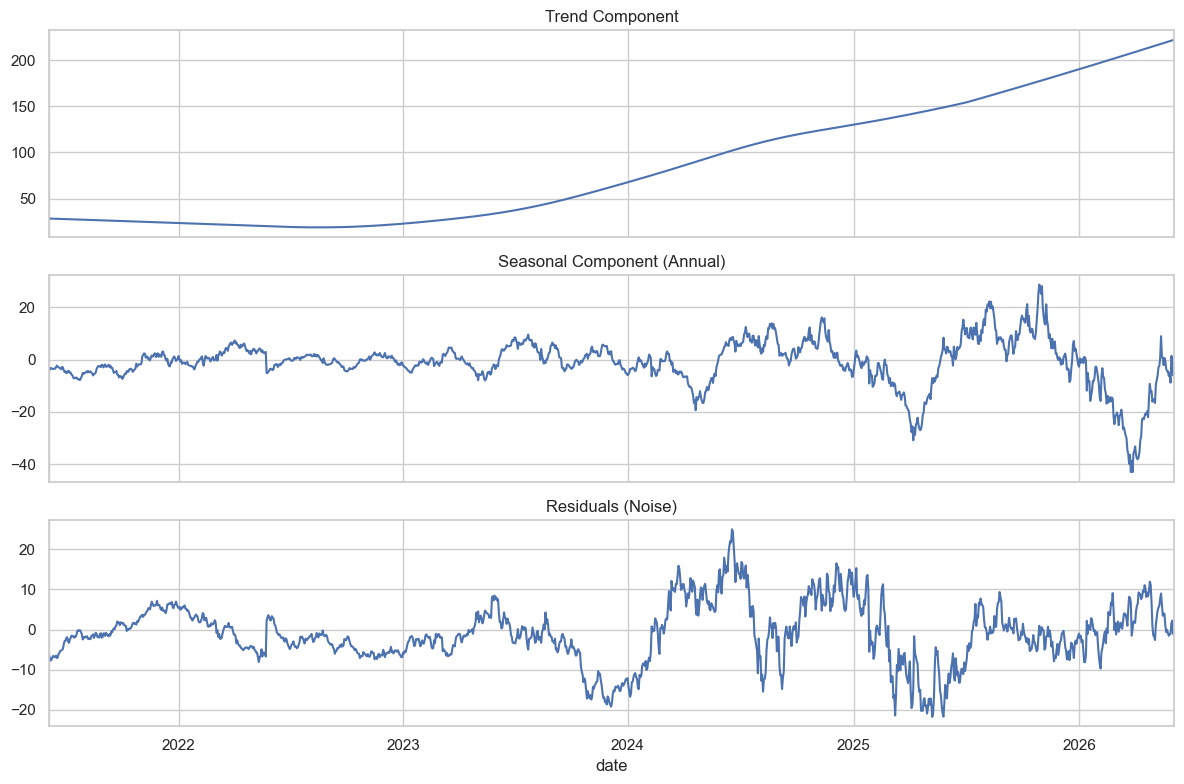

In [3]:
# Resample to business days for STL
stl_df = df['close'].asfreq('B').ffill()
stl = STL(stl_df, period=252)
res = stl.fit()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
res.trend.plot(ax=ax1, title="Trend Component")
res.seasonal.plot(ax=ax2, title="Seasonal Component (Annual)")
res.resid.plot(ax=ax3, title="Residuals (Noise)")
plt.tight_layout()
plt.show()

### 3. Stationarity Transformation
Applying log-differencing and verifying with the ADF test.

ADF Test for Log Returns:

--- ADF Test for Log Returns ---
ADF Statistic: -21.6715
p-value: 0.0000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


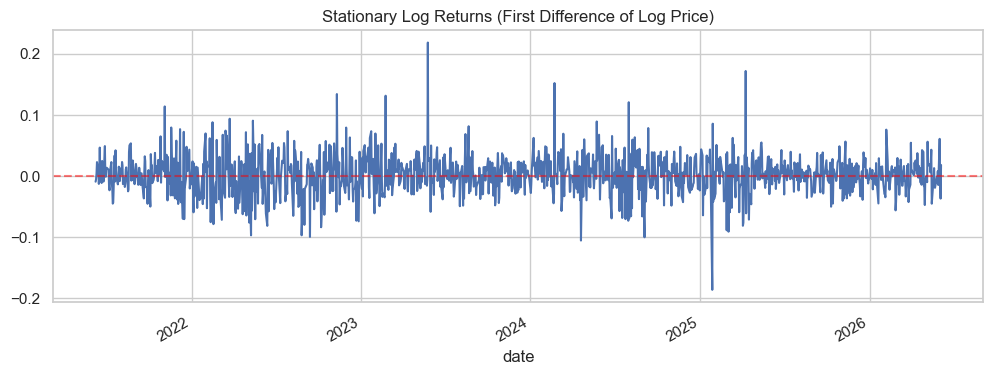

In [4]:
log_returns = np.log(df['close']).diff().dropna()

print("ADF Test for Log Returns:")
is_stationary = check_stationarity(log_returns, "Log Returns")

plt.figure(figsize=(12, 4))
log_returns.plot(title="Stationary Log Returns (First Difference of Log Price)")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

### 4. ML Feature Engineering
Using our `TimeSeriesPreprocessor` to generate scaled features without leakage.

Applying log transform...
Applying differencing (lags=1)...
Adding 5 lags...
Adding rolling features for windows: [5, 21]...
Performing time-series split (train_size=0.8)...
Applying standard scaling with Data Leakage protection...
Training set features: ['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'log_close', 'diff_log_close', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_21', 'rolling_std_21']


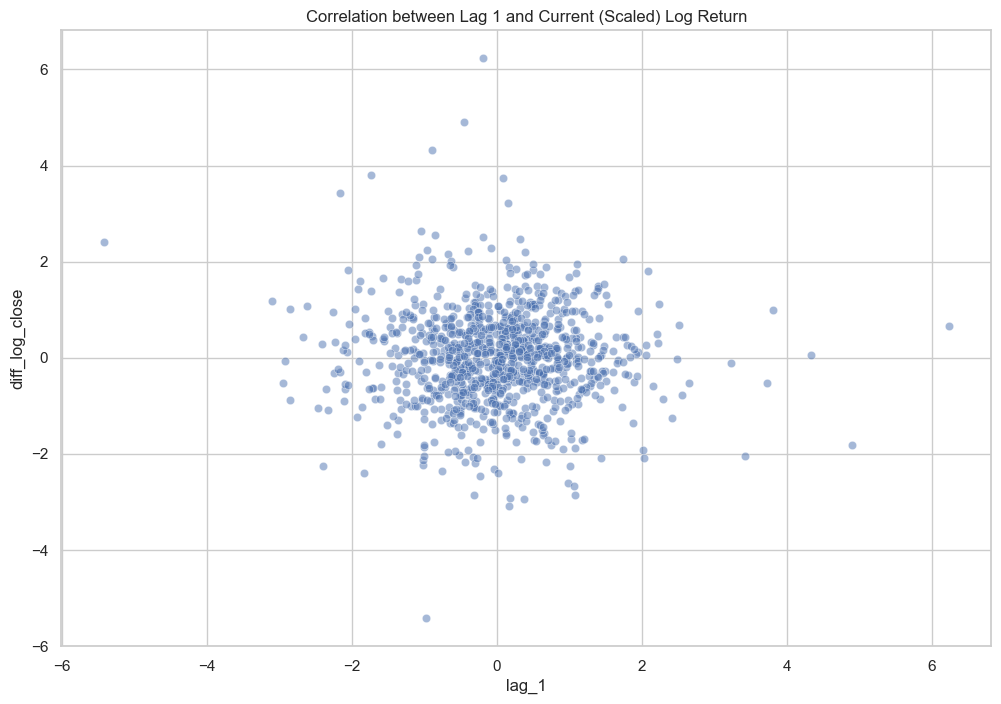

In [5]:
preprocessor = TimeSeriesPreprocessor(df.reset_index())

train, test = (preprocessor
                .log_transform()
                .difference()
                .add_lags(n_lags=5)
                .add_rolling_features(windows=[5, 21])
                .train_test_split(train_size=0.8)
                .scale(method='standard')
                .get_data())

print(f"Training set features: {train.columns.tolist()}")

# Visualize the relationship between lags and current price in scaled space
sns.scatterplot(data=train, x='lag_1', y='diff_log_close', alpha=0.5)
plt.title("Correlation between Lag 1 and Current (Scaled) Log Return")
plt.show()

### 5. Final Assessment
The pipeline successfully transformed raw, non-stationary stock prices into a set of stationary, scaled features suitable for autoregressive models or neural networks.